In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = r"H:\PYTHON\Etapa3\AnaliseTabela3\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"

dados = pd.read_excel(path, header=1)

In [4]:
dados = dados.iloc[1:33]

In [5]:
dados

,"Brasil, Grande Região e Unidade da Federação",Total,Unnamed: 2,Unnamed: 3,"Ciência, Tecnologia, Engenharias e Matemática",Unnamed: 5,Unnamed: 6,"Educação, Serviços pessoais, Saúde e Bem-estar",Unnamed: 8,Unnamed: 9
1,Brasil,25854291,10478534,15375757,4149041,2750422,1398619,8079707,1677985,6401723
2,Norte,1525166,590558,934609,209657,133055,76601,599785,141169,458616
3,Nordeste,4748933,1744994,3003939,621388,389993,231395,1822087,363905,1458181
4,Sudeste,12828829,5391638,7437191,2328122,1588874,739247,3652397,768288,2884108
5,Sul,4338861,1768855,2570005,662916,427372,235543,1256291,248574,1007718
6,Centro-Oeste,2412502,982489,1430013,326959,211124,115834,749148,156048,593101
7,Rondônia,164632,62766,101866,20538,11863,8675,63584,13963,49622
8,Acre,84300,33291,51009,10364,6237,4128,33379,9121,24258
9,Amazonas,342566,141059,201507,52669,34749,17919,121988,30738,91249
10,Roraima,67045,25585,41460,8016,4958,3057,23977,5880,18098


In [6]:

dados.columns = [
    "uf_regiao",
    "total",
    "Homens",
    "Mulheres",
    "Total_tec",
    "Homens_tec",
    "mulher_tec",
    "Total_edu",
    "Homens_edu",
    "mulher_edu",
]

In [7]:
df_limpo = dados

regioes_alvo = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

df_regioes = df_limpo[df_limpo["uf_regiao"].isin(regioes_alvo)].copy()

df_regioes


,uf_regiao,total,Homens,Mulheres,Total_tec,Homens_tec,mulher_tec,Total_edu,Homens_edu,mulher_edu
2,Norte,1525166,590558,934609,209657,133055,76601,599785,141169,458616
3,Nordeste,4748933,1744994,3003939,621388,389993,231395,1822087,363905,1458181
4,Sudeste,12828829,5391638,7437191,2328122,1588874,739247,3652397,768288,2884108
5,Sul,4338861,1768855,2570005,662916,427372,235543,1256291,248574,1007718
6,Centro-Oeste,2412502,982489,1430013,326959,211124,115834,749148,156048,593101


In [8]:
brasil = df_limpo[df_limpo["uf_regiao"] == "Brasil"].copy()

In [9]:
brasil

,uf_regiao,total,Homens,Mulheres,Total_tec,Homens_tec,mulher_tec,Total_edu,Homens_edu,mulher_edu
1,Brasil,25854291,10478534,15375757,4149041,2750422,1398619,8079707,1677985,6401723


In [10]:
superior = df_regioes[[0, 2, 3]].copy()
superior.columns = ["Regiao", "Homens_Superior", "Mulheres_Superior"]

superior.to_excel("superior.xlsx", index=False)

print("--- ESTATÍSTICAS: CURSO SUPERIOR GERAL ---")
print(superior.describe())
print("\n" + "="*50 + "\n")


tecnologia = df_regioes[[0, 5, 6]].copy()
tecnologia.columns = ["Regiao", "Homens_Tecnologia", "Mulheres_Tecnologia"]

tecnologia.to_excel("tecnologia.xlsx", index=False)

print("--- ESTATÍSTICAS: CIÊNCIA, TECNOLOGIA, ENGENHARIAS E MATEMÁTICA ---")
print(tecnologia.describe())
print("\n" + "="*50 + "\n")


educacao_saude = df_regioes[[0, 8, 9]].copy()
educacao_saude.columns = ["Regiao", "Homens_Educacao_Saude", "Mulheres_Educacao_Saude"]

educacao_saude.to_excel("educacao_saude.xlsx", index=False)

print("--- ESTATÍSTICAS: EDUCAÇÃO, SERVIÇOS, SAÚDE E BEM-ESTAR ---")
print(educacao_saude.describe())

KeyError: "None of [Index([0, 2, 3], dtype='int64')] are in the [columns]"

In [36]:
formacao_total = superior
formacao_stem = tecnologia
formacao_saude = educacao_saude

In [44]:
brasil = df_limpo.iloc[0:1]

In [45]:
brasil

,0,1,2,3,4,5,6,7,8,9
0,Brasil,25854291.0,10478534.0,15375757.0,4149041.0,2750422.0,1398619.0,8079707.0,1677985.0,6401723.0


In [68]:
# Barras agrupadas: homens x mulheres no Brasil (três recortes)
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["Regiao"] == "Brasil", "Homens_Superior"].item(),
            formacao_stem.loc[formacao_stem["Regiao"] == "Brasil", "Homens_Tecnologia"].item(),
            formacao_saude.loc[formacao_saude["Regiao"] == "Brasil", "Homens_Educacao_Saude"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["Regiao"] == "Brasil", "Mulheres_Superior"].item(),
            formacao_stem.loc[formacao_stem["Regiao"] == "Brasil", "Mulheres_Tecnologia"].item(),
            formacao_saude.loc[formacao_saude["Regiao"] == "Brasil", "Mulheres_Educacao_Saude"].item(),
        ],
    }
)
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

ValueError: can only convert an array of size 1 to a Python scalar

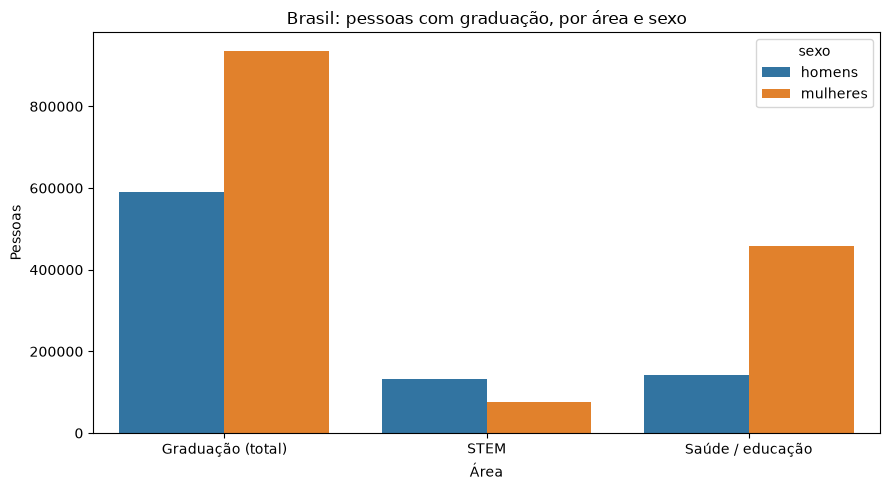

In [38]:

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()